## **Load packages**

In [3]:
import numpy as np
import pandas as pd
import random

import os

# tf
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img

# shap
import shap

# plots and images
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image

# silence TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

random.seed(2)

In [4]:
import os
from google.colab import drive
import random

# --- CLEANUP STEP ---
# This removes any accidental folders created in /content/drive
# during previous failed attempts so the mount can succeed.
if os.path.exists('/content/drive'):
    import shutil
    try:
        shutil.rmtree('/content/drive')
    except:
        pass

# --- STEP 1: Mount Google Drive ---
# This will trigger the pop-up to authorize access.
drive.mount('/content/drive')

# --- STEP 2: Create your custom cache folder INSIDE your Drive ---
# We use 'MyDrive' which is the standard root of your Google Drive.
cache_path = '/content/drive/MyDrive/tf_hub_cache'
os.makedirs(cache_path, exist_ok=True)

# --- STEP 3: Tell TensorFlow Hub to use that specific folder ---
os.environ['TFHUB_CACHE_DIR'] = cache_path

Mounted at /content/drive


#### **1) from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img**
These are used to convert images between different formats(files, array, PIL images) for use in deep learning models.
1) **load_img:** loads an image from a file path into a PIL (Python Imaging Library) object. It allows you to specify parameters like `target_size` to resize the image automatically during loading.
2) **img_to_array:** converts a PIL image object into a numpy array. This si necessary because neural networks require numerical data (tensors/arrays) as input rather than raw image objects.
3) **array_to_img:** the reverse of `img_to_array`. It converts a numpy array back into a PIL image object, which is useful for visualizing predictions or saving processed images to your disk.

#### **2) shap - SHapley Additive exPlanations**
It is a library used to explain the output of machine learning models. It works by calculating Shapley values, a concept from game theory, to determine how much each individual feature contributed to a specific prediction.
Here is what SHAP specifically does:

**1) Feature Importance (Global Interpretability)**
- Instead of just telling you which features are important for the whole model, SHAP shows how much each feature pushes the prediciton higher or lower across your entire dataset. It helps you understand the 'big picture' logic of the model.

**2) Local Explanations (Individual Predictions)**
- SHAP can explain a single specific prediction. For example, if a loan application was rejected, SHAP can tell you exactly which factors (e.g. low credit score, high debt-to-income ration) were responsible for that specific decision.

**3) Quantifying Feature Impace (Directionality)**
- Unlike standard feature importance (which only tells you that a feature is important), SHAP tells you the direciton of the impact:
- Does a high valu of 'Age' increase or decrease the probability of the outcome?
- It quantifies whether a feature pushed the prediction toward the positive class or the negative class.

**4) Visualizing Model Behavior**
- The library provides powerful visualization tools:
    - `Summary plots:` A dot plots showing the distribution of impacts for every feature across all samples.
    - `Force plots:` A visualization of how different features 'pushed' a single prediction from the base value (the average model output) to the final predicted value.
    - `Dependence plots:` Shows the relationship between a single feature's value and its impact on the prediction.

## **Load Data**

In [5]:
BASE = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Brain_Tumor'

# BASE = 'Brain_Tumor'
IMG_SIZE = (224, 224) # set up image size when loading

# load image from folder, split would used to load training or test data. There are two separate folder 'test' and 'train' under BASE
def load_split(split):
    # Read the folder
    split_dir = os.path.join(BASE, split)
    # read class from folder name
    classes = sorted(c for c in os.listdir(split_dir)
                     if os.path.isdir(os.path.join(split_dir, c)))
    # convert string to int
    cls_to_idx = {c: i for i, c in enumerate(classes)}

    X, y = [], []
    # read images from each folder, transform classes to interger
    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            img = load_img(fpath, target_size=IMG_SIZE)
            X.append(img_to_array(img)) # convert image to array, and append to list
            y.append(cls_to_idx[cls]) # convert label to number

    # conver from list to array, shuffle the data
    X = np.array(X)
    y = np.array(y)

    idx = np.random.permutation(np.arange(len(X)))
    X = X[idx]
    y = y[idx]

    # return the X, y, and string classes
    return np.array(X), np.array(y), classes

# load training data and test data
X_train, y_train, classes = load_split('train')
X_test, y_test, _ = load_split('test')

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(classes)

(5723, 224, 224, 3) (5723,)
(1430, 224, 224, 3) (1430,)
['glioma', 'meningioma', 'notumor', 'pituitary']


#### **1) Convert data from numpy array to tensor**
- convert from array to tensor, TensorFlow needs the data to be in a specific structure called Tensor. Tensors are special because they are designed to live on the GPU and can track 'gradients' (the history of mathematical operations) so the model knows how to update itself.


In [6]:
X_train = tf.convert_to_tensor(X_train / 255.0, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test / 255.0, dtype=tf.float32)

#### **2) Review few images**

<span style='color:chocolate'>Review one Image</span>

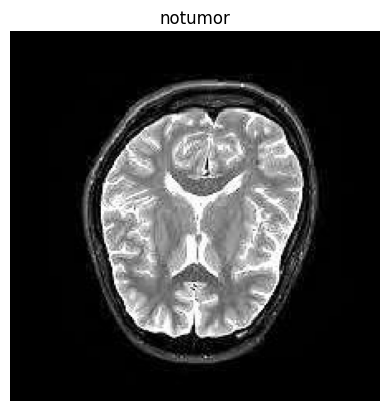

In [7]:
plt.imshow(array_to_img(X_train[0]))
plt.title(classes[y_train[0]])
plt.axis('off')
plt.show()

<span style='color:chocolate'>Review ten images</span>

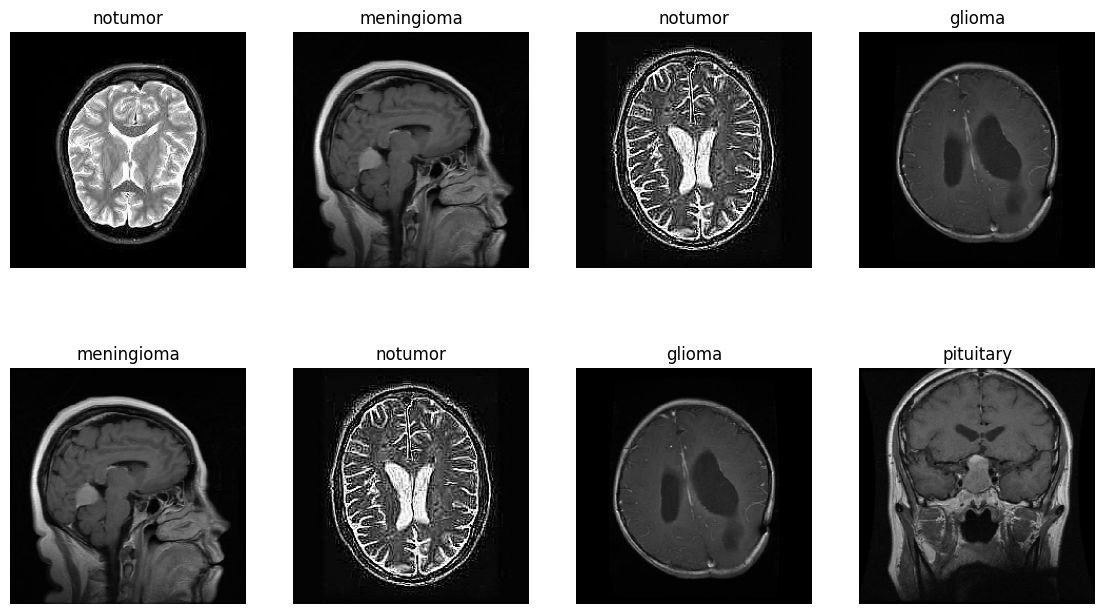

In [8]:
nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(14,8))

for i in range(nrows):
    for j in range(ncols):
        axes[i, j].imshow(array_to_img(X_train[i+j]))
        axes[i, j].set_title(classes[y_train[i+j]])
        axes[i, j].axis('off')

#### **3) Review class distribution**

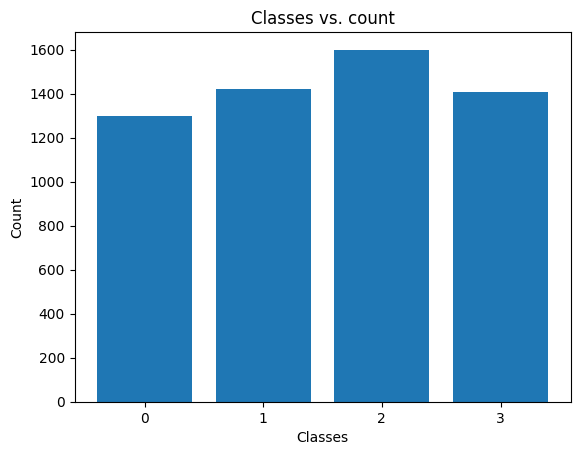

In [9]:
classes_count = pd.DataFrame(y_train).value_counts()
idx = [x[0] for x in classes_count.index.tolist()] # convert index (classes) to list

plt.bar(idx, classes_count.values)
plt.xticks(idx)
plt.title('Classes vs. count')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

#### **4) Augment images**

In [10]:
Img_size = (224, 224)
Delta = 0.3 # brightness
Contrast_f = 3 # contrast ratio

# image resize - we set the size when load the image, here just show another function - resize through tf.image.resize()
X_train = tf.image.resize(X_train, Img_size)
X_test = tf.image.resize(X_test, Img_size)

# scale pixel from 3 dimensions to 1 dimension
X_train = tf.image.rgb_to_grayscale(X_train)
X_test = tf.image.rgb_to_grayscale(X_test)

# adjust brightness - only apply to the test data, test data should be changed
X_train_augm = tf.image.adjust_brightness(X_train, delta=Delta)

# adjust contrast
X_train_augm = tf.image.adjust_contrast(X_train_augm, contrast_factor=Contrast_f)

# flip
X_train_augm = tf.image.flip_left_right(X_train_augm)

# combine the augm with original, augmentation is just create new training samples based on existed ones - simple and cheap
X_train = tf.concat([X_train, X_train_augm], axis=0)
y_train = tf.concat([y_train, y_train], axis=0)

# shuffle
shuffle = np.random.permutation(np.arange(len(X_train)))
X_train = tf.gather(X_train, shuffle)
y_train = tf.gather(y_train, shuffle)

#### **1) contrast_factor = 3:**
The `contrast_factor` scales the difference between each pixel's intensity and the mean intensity of the image.

Mathematically, it performs the following operation on every pixel:
$$\text{New Pixel Value} = (\text{Original Pixel Value} - \text{Mean Intensity}) \times \text{contrast\_factor} + \text{Mean Intensity}$$

*   **If factor > 1:** It pushes pixel values further away from the mean, making bright pixels brighter and dark pixels darker (increasing contrast).
*   **If factor is between 0 and 1:** It pulls pixel values closer to the mean, reducing the difference between light and dark areas (decreasing contrast/making it "flatter").
*   **If factor = 1:** The image remains unchanged.

#### **2) tf.gather()**
tf.gather() picks rows from the tensor in the order given by the index tensor
#
---
#

## **Model - FFNN; CNN; TensorFlow Hub**

### **1) Build the model - FFNN**

In [11]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

# we don't use tf.keras.Sequence(), use tf.keras.models.Model()
input1 = tf.keras.layers.Input(shape=(224,224,1), name='input1')
x = tf.keras.layers.Flatten(name='Flatten')(input1)
x = tf.keras.layers.Dense(256, activation='relu', name='fc_1',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001))(x) # 0.001 is lambda
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(rate=0.3, name='Dropout')(x)
out = tf.keras.layers.Dense(units=4, activation=None, name='out')(x) # activation=None, would reture the percentages - logits

model_fnn = tf.keras.models.Model(inputs=input1, outputs=out)

# model compile
model_fnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

# early stop
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# initialize the model
history_fnn = model_fnn.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop])

Epoch 1/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6215 - loss: 1.3704 - val_accuracy: 0.7615 - val_loss: 1.2472
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7016 - loss: 1.0805 - val_accuracy: 0.7902 - val_loss: 1.1938
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7044 - loss: 1.0214 - val_accuracy: 0.5378 - val_loss: 1.4428
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7111 - loss: 0.9791 - val_accuracy: 0.6280 - val_loss: 1.1661
Epoch 5/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6760 - loss: 1.0400 - val_accuracy: 0.2888 - val_loss: 1.7420
Epoch 6/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6317 - loss: 1.1198 - val_accuracy: 0.6441 - val_loss: 1.1725
Epoch 7/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6822 - loss: 1.0011 - val_accuracy: 0.5252 - val_loss: 1.2079
Epoch 8/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7031 - loss: 0.9620 - val_accuracy: 

FFNN model can't achive good accuracy on both trainin gand validation dataset. FFNN is just not to image classification.

#### **1) BatchNormalization**

`tf.keras.layers.BatchNormalization` performs the following operations on the input tensor `x` during training:

1.  **Calculates Mean and Variance:** It computes the mean and variance of the features across the batch dimension for each channel.
2.  **Normalizes:** It subtracts the mean and divides by the standard deviation (plus a small epsilon to avoid division by zero) to transform the data to have a mean of approximately 0 and a variance of approximately 1.
3.  **Scales and Shifts:** It applies two learnable parameters, **gamma** ($\gamma$, scale) and **beta** ($\beta$, offset), to the normalized values: $y = \gamma \cdot \hat{x} + \beta$. This allows the network to undo the normalization if that is optimal for learning.

**Key Benefits:**
*   **Faster Convergence:** It reduces "internal covariate shift," allowing for higher learning rates.
*   **Stabilizes Training:** It makes the network less sensitive to initial weight distributions.
*   **Regularization Effect:** The noise introduced by calculating statistics on mini-batches acts as a slight regularizer, often reducing the need for Dropout.

#### **2) early_stop:**

This code defines a callback used during model training to prevent **overfitting** by stopping the training process once the model stops improving.

Here is a breakdown of each parameter:

*   **`monitor='val_loss'`**: The callback watches the validation loss. It looks for this value to stop decreasing; if the loss starts increasing, it signals that the model may be overfitting.
*   **`patience=5`**: This defines the "grace period." The training will not stop immediately when the `val_loss` stops improving. Instead, it will wait for **5 consecutive epochs** of no improvement. If the loss does not improve within these 5 epochs, the training process is terminated.
*   **`restore_best_weights=True`**: This is a critical feature. When training stops, the model's weights are usually at their "worst" (the point after 5 epochs of degradation). Setting this to `True` ensures that after training stops, the model automatically rolls back its weights to the version that achieved the **lowest** `val_loss` recorded during the session.

**Summary of behavior:** If the validation loss fails to improve for 5 straight epochs, the training stops and the model reverts to the state it was in when it performed best.

### **2) Fit Model - CNN**

In [12]:
input1 = tf.keras.layers.Input(shape=(224,224,1), name='input1')

# CNN
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(input1)
x = tf.keras.layers.MaxPooling2D((2,2))(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2,))(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)

# feed to FNN
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
out = tf.keras.layers.Dense(4, activation=None)(x)

# initialize the model
model_cnn = tf.keras.models.Model(inputs=input1, outputs=out)

# compile
model_cnn.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# early stop
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# initialize the model
history_cnn = model_cnn.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop])

Epoch 1/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.7768 - loss: 0.5979 - val_accuracy: 0.8692 - val_loss: 0.4743
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9272 - loss: 0.2123 - val_accuracy: 0.7448 - val_loss: 0.8083
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9757 - loss: 0.0862 - val_accuracy: 0.9315 - val_loss: 0.2142
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9900 - loss: 0.0423 - val_accuracy: 0.9441 - val_loss: 0.1767
Epoch 5/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9949 - loss: 0.0228 - val_accuracy: 0.9699 - val_loss: 0.1236
Epoch 6/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9964 - loss: 0.0158 - val_accuracy: 0.9420 - val_loss: 0.1926
Epoch 7/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9989 - loss: 0.0085 - val_accuracy: 0.9692 - val_loss: 0.1117
Epoch 8/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9992 - loss: 0.0052 - val_acc

CNN model is much better compare with the FNN model. For CNN model as training accuracy as 0.9969 and val_accuracy as 0.9517, which is really good.
#
---

This code defines two fundamental operations used in Convolutional Neural Networks (CNNs) to extract features from an image. Here is the step-by-step breakdown:

#### 1. The Convolutional Layer (`Conv2D`)
`x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(input1)`

This layer is the "eye" of the model. It scans the input image to find patterns (like edges, textures, or shapes).

*   **`32` (Filters):** This tells the layer to create **32 different filters** (also called kernels). Each filter is looking for something different (e.g., one looks for vertical lines, another for horizontal lines, another for color gradients).
*   **`(3,3)` (Kernel Size):** This is the size of the "window" that slides across the image. A $3 \times 3$ window is the industry standard. It looks at a $3 \times 3$ patch of pixels at a time.
*   **`activation='relu'`:** After the convolution math is done, the result is passed through the **Rectified Linear Unit (ReLU)** function.
    *   **What it does:** It turns all negative pixel values to **0** and keeps positive values as they are.
    *   **Why:** This introduces "non-linearity," allowing the model to learn complex patterns rather than just simple linear math.
*   **`(input1)`:** This tells Keras that the input for this layer is the tensor named `input1`.

**Result of this step:** You get a "feature map" that is deeper (32 layers deep) but contains information about where specific patterns were found in the image.


#### 2. The Pooling Layer (`MaxPooling2D`)
`x = tf.keras.layers.MaxPooling2D((2,2))(x)`

This layer is the "summarizer." It reduces the size of the data to make the model faster and more robust.

*   **`((2,2))` (Pool Size):** This tells the layer to look at the image in $2 \times 2$ blocks.
*   **How it works (Max Pooling):** Within every $2 \times 2$ block, the layer looks at the 4 pixels and **only keeps the largest value**, throwing the other 3 away.
*   **Why do this?**
    1.  **Dimensionality Reduction:** It reduces the width and height of the image by half. This makes the model much faster and uses less memory.
    2.  **Translation Invariance:** Because it only takes the *maximum* value, if a feature (like an eye) shifts slightly to the left or right, the "max" value in that area remains the same. This makes the model better at recognizing objects even if they aren't perfectly centered.


#### Summary of the Workflow
1.  **Input:** You start with a raw image (e.g., $224 \times 224 \times 3$).
2.  **Conv2D:** The model creates 32 different "feature maps" using $3 \times 3$ filters. The image is now "deeper" (32 channels).
3.  **ReLU:** It cleans up the data by removing negative values.
4.  **MaxPooling2D:** It shrinks the image size (e.g., from $224 \times 224$ down to $112 \times 112$) by picking the most important (highest) pixel in every $2 \times 2$ area.
#
---
#

### **3) Transfer Learning - EfficientNetB0**

`import tensorflow_hub as hub` is the command used to load the **TensorFlow Hub** library into your Python environment.

### What is TensorFlow Hub?
TensorFlow Hub is a massive repository of **pre-trained machine learning models**. Instead of training a massive model (like a complex image recognizer or a language translator) from scratch—which could take weeks and thousands of dollars in GPU costs—you can download a model that has already been trained by experts (like Google) and use it immediately.

### Why use it?
1.  **Transfer Learning:** This is the most common use case. You take a model that already knows how to "see" (like MobileNet or ResNet) and you just "fine-tune" it to recognize your specific objects (e.g., instead of recognizing "everything," it only recognizes "your specific brand of soda").
2.  **Speed:** It saves massive amounts of time. You can go from a raw dataset to a working model in minutes.
3.  **State-of-the-Art Performance:** You get access to highly optimized models that are difficult to build from scratch.

### Common Use Cases
*   **Computer Vision:** Image classification, object detection, image segmentation, and feature extraction.
*   **NLP (Natural Language Processing):** Text classification, sentence embeddings, and language translation.
*   **Audio:** Sound classification and speech recognition.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import tensorflow_hub as hub
from tensorflow.keras.applications import EfficientNetB0

In [14]:
# load the pre-trained EfficientNetB0 (weigths from ImageNet)
img_layer = EfficientNetB0(weights='imagenet',
                           include_top=False, # only use the conv learned features (1280 numbers), not the head - 1000 probabilites only sueful for ImageNet.
                           input_shape=IMG_SIZE + (3,),
                           pooling='avg')
img_layer.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

Num_classes = 4

img_model = models.Sequential([
    img_layer,
    layers.Dense(256, activation='relu'),
    #layers.BatchNormalization(),
    #layers.Dropout(0.5),

    #layers.Dense(128, activation='relu'),
    #layers.BatchNormalization(),
    #layers.Dropout(0.5),

    #layers.Dense(64, activation='relu'),
    #layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(Num_classes, activation='softmax')
])


img_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])


# Phase 1: Training the head
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# The array now has a shape of (N, 224, 224, 3). It is still visually a grayscale image, but the computer now treats it as an RGB image where Red = Green = Blue.
X_train_rgb = np.repeat(X_train, 3, axis=-1)  # (N, 224, 224, 1) -> (N, 224, 224, 3)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

img_history = img_model.fit(X_train_rgb * 255.0, y_train,
          validation_data=(X_test_rgb * 255.0, y_test),
          epochs=50,
          callbacks=[early_stop])

Epoch 1/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 78s 120ms/step - accuracy: 0.7977 - loss: 0.5282 - val_accuracy: 0.8874 - val_loss: 0.3006
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8714 - loss: 0.3378 - val_accuracy: 0.9112 - val_loss: 0.2376
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8929 - loss: 0.2929 - val_accuracy: 0.9161 - val_loss: 0.2236
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9015 - loss: 0.2626 - val_accuracy: 0.9322 - val_loss: 0.1941
Epoch 5/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9095 - loss: 0.2426 - val_accuracy: 0.9420 - val_loss: 0.1738
Epoch 6/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9210 - loss: 0.2122 - val_accuracy: 0.9385 - val_loss: 0.1730
Epoch 7/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9259 - loss: 0.2000 - val_accuracy: 0.9406 - val_loss: 0.1644
Epoch 8/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9299 - loss: 0.1873 - val_ac

**Why are we doing this? X_train_rgb = np.repeat(X_train, 3, axis=-1)**
- we are doing this because we are using a pre-trained model like EfficientNet or ResNet.

- These models were originally trained on the ImageNet dataset, which consists of full-color RGB photos. Because of this, their "input layer" is hardcoded to expect exactly 3 input channels. If we try to feed them a 1-channel grayscale image, the model will throw a ValueError because the math (the matrix multiplications) won't align with the expected input shape.



### **4) Transfer Learning - TensorFlow Hub**

In [16]:
# pip install tf_keras

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras
from tf_keras import layers, models

In [17]:

# Define the number of classes in your Brain Tumor dataset
NUM_CLASSES = 4 # e.g., Glioma, Meningioma, Pituitary, No Tumor

def build_vit_model(vit_trainable=False):
    vit_layer = hub.KerasLayer(
        "https://tfhub.dev/sayakpaul/vit_b16_fe/1",
        trainable=vit_trainable,
        input_shape=IMG_SIZE + (3,) # add a new level as ( height, width, num_channels)
    )

    model = models.Sequential([
        vit_layer, # add the layer for the pre-trained ViT model
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model_vit = build_vit_model(vit_trainable=False)
model_vit.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# Phase 1: Training the head
early_stop = tf_keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

X_train_rgb = np.repeat(X_train, 3, axis=-1)  # (N, 224, 224, 1) -> (N, 224, 224, 3)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

history_model_vit = model_vit.fit(X_train_rgb, y_train,
          validation_data=(X_test_rgb, y_test),
          epochs=50,
          callbacks=[early_stop])

Epoch 1/50
358/358 [==============================] - 12s 34ms/step - loss: 0.0660 - accuracy: 0.9752 - val_loss: 0.1218 - val_accuracy: 0.9671
Epoch 2/50
358/358 [==============================] - 11s 31ms/step - loss: 0.0630 - accuracy: 0.9757 - val_loss: 0.1210 - val_accuracy: 0.9622
Epoch 3/50
358/358 [==============================] - 11s 31ms/step - loss: 0.0634 - accuracy: 0.9757 - val_loss: 0.1156 - val_accuracy: 0.9601
Epoch 4/50
358/358 [==============================] - 11s 31ms/step - loss: 0.0530 - accuracy: 0.9800 - val_loss: 0.1363 - val_accuracy: 0.9671
Epoch 5/50
358/358 [==============================] - 11s 31ms/step - loss: 0.0558 - accuracy: 0.9787 - val_loss: 0.1473 - val_accuracy: 0.9615
Epoch 6/50
358/358 [==============================] - 11s 31ms/step - loss: 0.0605 - accuracy: 0.9779 - val_loss: 0.1388 - val_accuracy: 0.9657
Epoch 7/50
358/358 [==============================] - 11s 30ms/step - loss: 0.0430 - accuracy: 0.9831 - val_loss: 0.1220 - val_accuracy:

### **3) Transfer Learning - fine-tuning**

In [25]:
# Phase 2: Fine-tuning (Unfreeze some vit_layer)

# Use a much smaller learning rate for fine-tuning to avoid destroying pre-trained weights
import tf_keras

# unfreeze the ViT backbone. Unfreezing it makes the whole ~86M-param ViT-B16 backbone trainable.
model_vit.layers[0].trainable = True

# Recompile with a small LR so we don't wreck the pretrained weights.
model_vit.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.00001),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [26]:
# check the trainable parameter
model_vit.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 768)               85798656  
                                                                 
 dense (Dense)               (None, 256)               196864    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 85996548 (328.05 MB)
Trainable params: 85996548 (328.05 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
early_stop = tf_keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_vit_finetune = model_vit.fit(X_train_rgb, y_train, # input be range [0,1], it is difference from EfficientNet model.
                     epochs=20,
                     batch_size=32,
                     validation_data=(X_test_rgb, y_test),
                     callbacks=[early_stop])
model_vit.save_weights('model_posttrain_weights.h5')

Epoch 1/20


### **Does model.layers[0].trainable = True wold destroy the original ViT model:**
- model.layers[0].trainable = True just flips a flag. It tells the optimizer "you're now allowed to compute gradients for these weights." At that instant, the ViT weights are still exactly the pretrained ImageNet values — nothing has changed. No destruction happens from the flag itself.
What modifies the weights is model.fit() afterward. That's where the pretrained weights get updated by gradient descent. So the real question is: will fine-tuning corrupt the useful features the ViT learned? It can, but only if you're careless. Two things protect you:

- The small learning rate (1e-5). This is the whole reason you use a tiny LR in Phase 2. The pretrained weights move only in small steps, so you're gently adapting them to brain MRI rather than overwriting them. A large LR (say 1e-3) would blow away the pretrained features fast — that's the actual "destroy the model" failure mode, and it's why your Phase 2 code correctly uses 1e-5.

- restore_best_weights=True. Even if fine-tuning goes badly, early stopping rolls you back to the best checkpoint. Worst realistic case, you land back near your Phase 1 performance, not below it.

- The weights on disk at https://tfhub.dev/sayakpaul/vit_b16_fe/1 are never touched. You're only modifying the in-memory copy loaded into model. The original pretrained ViT is completely safe — you could rebuild a fresh copy any time.

- But your Phase-1-trained model object is mutated in place by fit(). If you want to keep your Phase 1 result as a fallback while you experiment, save it first: model.save_weights('phase1_head.weights.h5')

### **Final Summary:**
- Phase 2 - Fine-tuning actually doesn't improve the accuracy comparing with the model without fine-tuning.
- CNN already generates great accuracy (goog model), but model wihtout fine-tuning return the best balance.